<a href="https://colab.research.google.com/github/sumeyyeep1/LSB-Image-Steganography/blob/main/steganography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# Blok 1: Gerekli kütüphaneler
from PIL import Image
import numpy as np
from google.colab import files

Lütfen bir PNG veya JPG görsel dosyası seçin:


Saving doga.webp to doga.webp

✅ Görsel yüklendi: 'doga.webp'


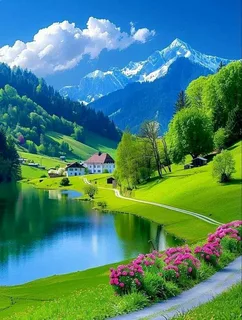

In [47]:
# Blok 2: Kendi görselini yükle
print("Lütfen bir PNG veya JPG görsel dosyası seçin:")
yuklenen = files.upload()

# Yüklenen ilk dosyanın adını al
gorsel_adi = list(yuklenen.keys())[0]
print(f"\n✅ Görsel yüklendi: '{gorsel_adi}'")

# Görseli ekranda önizle
from IPython.display import display
display(Image.open(gorsel_adi))

In [48]:
# Blok 3: Encode fonksiyonu (LSB yöntemi)
def encode(image_path, message, output_path):
    img = Image.open(image_path).convert("RGB")
    pixels = np.array(img)

    message += "<<<END>>>"
    binary_message = ''.join(format(ord(c), '08b') for c in message)
    total_bits = len(binary_message)

    flat = pixels.flatten()

    if total_bits > len(flat):
        raise ValueError(f"Mesaj çok uzun! Bu görsele max {len(flat) // 8} karakter sığar.")

    for i in range(total_bits):
        flat[i] = (flat[i] & 0b11111110) | int(binary_message[i])

    result_img = Image.fromarray(flat.reshape(pixels.shape).astype(np.uint8))
    result_img.save(output_path)
    print(f"✅ Mesaj gömüldü → '{output_path}'")
    print(f"   Karakter sayısı : {len(message) - len('<<<END>>>')}")
    print(f"   Toplam bit      : {total_bits}")

print("✅ Encode fonksiyonu tanımlandı.")

✅ Encode fonksiyonu tanımlandı.


In [49]:
# Blok 4: Decode fonksiyonu
def decode(image_path):
    img = Image.open(image_path).convert("RGB")
    flat = np.array(img).flatten()

    bits = [str(flat[i] & 1) for i in range(len(flat))]

    chars = []
    for i in range(0, len(bits) - 7, 8):
        char = chr(int(''.join(bits[i:i+8]), 2))
        chars.append(char)
        if ''.join(chars[-9:]) == "<<<END>>>":
            return ''.join(chars[:-9])

    return "⚠️ Mesaj bulunamadı."

print("✅ Decode fonksiyonu tanımlandı.")

✅ Decode fonksiyonu tanımlandı.


      🕵️  Stenografi Aracı — ENCODE
Yüklenen görsel: doga.webp

Gizlenecek mesajı yazın: Sümeyye Polat
✅ Mesaj gömüldü → 'output_doga.png'
   Karakter sayısı : 13
   Toplam bit      : 176

📁 Çıktı dosyası: 'output_doga.png'

Encode edilmiş görsel önizlemesi:


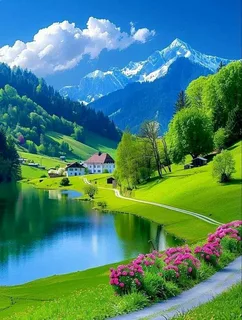


➡️  Şimdi Blok 6'yı çalıştırarak testi yapabilirsin.


In [50]:
# Blok 5A: Encode - görsele mesaj göm
print("=" * 45)
print("      🕵️  Stenografi Aracı — ENCODE")
print("=" * 45)
print(f"Yüklenen görsel: {gorsel_adi}\n")

mesaj = input("Gizlenecek mesajı yazın: ").strip()
cikti = "output_" + gorsel_adi.split(".")[0] + ".png"

try:
    encode(gorsel_adi, mesaj, cikti)
    print(f"\n📁 Çıktı dosyası: '{cikti}'")
    print("\nEncode edilmiş görsel önizlemesi:")
    display(Image.open(cikti))
    print("\n➡️  Şimdi Blok 6'yı çalıştırarak testi yapabilirsin.")
except Exception as e:
    print(f"❌ Hata: {e}")

In [52]:
# Blok 5B: Decode - görselden mesajı çıkar
# Bu bloğu encode edilmiş bir görseli test etmek için çalıştır

print("=" * 45)
print("      🕵️  Stenografi Aracı — DECODE")
print("=" * 45)

decode_gorsel = input("Decode edilecek görselin adı (örn: output_input.png): ").strip()

try:
    sonuc = decode(decode_gorsel)
    print(f"\n🔍 Çıkarılan mesaj:\n\n   → {sonuc}\n")
    print("✅ Decode başarıyla tamamlandı!")
except Exception as e:
    print(f"❌ Hata: {e}")

      🕵️  Stenografi Aracı — DECODE
Decode edilecek görselin adı (örn: output_input.png): output_doga.png

🔍 Çıkarılan mesaj:

   → Sümeyye Polat

✅ Decode başarıyla tamamlandı!


In [51]:
# Blok 6: Encode edilen dosyayı otomatik decode ile doğrula
# ⚠️ Bu bloğu SADECE Blok 5A'dan sonra çalıştır

cikti_dosyasi = "output_" + gorsel_adi.split(".")[0] + ".png"

print(f"Test ediliyor: '{cikti_dosyasi}'\n")

try:
    okunan = decode(cikti_dosyasi)
    print(f"🔍 Çıkarılan mesaj: {okunan}")

    # Orijinal mesajla karşılaştır
    if okunan == mesaj:
        print("✅ TEST BAŞARILI — Encode ve decode tam eşleşti!")
    else:
        print("❌ TEST BAŞARISIZ — Mesajlar eşleşmiyor.")
except Exception as e:
    print(f"❌ Hata: {e}")

Test ediliyor: 'output_doga.png'

🔍 Çıkarılan mesaj: Sümeyye Polat
✅ TEST BAŞARILI — Encode ve decode tam eşleşti!


In [45]:
# Blok 7: Encode edilmiş görseli indir
# ⚠️ Bu bloğu SADECE Blok 5A'dan sonra çalıştır

cikti_dosyasi = "output_" + gorsel_adi.split(".")[0] + ".png"
files.download(cikti_dosyasi)
print(f"⬇️ '{cikti_dosyasi}' indiriliyor...")

FileNotFoundError: Cannot find file: output_output_doga (1) (1).png